In [ ]:
# Install package
install.packages("tidyverse")
install.packages("dplyr")
install.packages("broom")

In [2]:
# Libraries
library(tidyverse)
library(dplyr)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [16]:
# Load Data
cpa <- read.delim("marketing_campaign.csv")
head(cpa)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2,2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
3,4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
4,6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5,5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
6,7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0


In [17]:
#Number of observations & variables
glimpse(cpa)

#Table
data.frame(Type = sapply(cpa, class))

Rows: 2,240
Columns: 29
$ ID                  <int> 5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 485…
$ Year_Birth          <int> 1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 19…
$ Education           <chr> "Graduation", "Graduation", "Graduation", "Graduat…
$ Marital_Status      <chr> "Single", "Single", "Together", "Together", "Marri…
$ Income              <int> 58138, 46344, 71613, 26646, 58293, 62513, 55635, 3…
$ Kidhome             <int> 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ Teenhome            <int> 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,…
$ Dt_Customer         <chr> "04-09-2012", "08-03-2014", "21-08-2013", "10-02-2…
$ Recency             <int> 58, 38, 26, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82…
$ MntWines            <int> 635, 11, 426, 11, 173, 520, 235, 76, 14, 28, 5, 6,…
$ MntFruits           <int> 88, 1, 49, 4, 43, 42, 65, 10, 0, 0, 5, 16, 61, 2, …
$ MntMeatProducts     <int> 546, 6, 127, 20, 118, 98, 164, 56, 24, 6, 6, 11, 4…
$ MntFishProduct

,Type
,<chr>
ID,integer
Year_Birth,integer
Education,character
Marital_Status,character
Income,integer
Kidhome,integer
Teenhome,integer
Dt_Customer,character
Recency,integer


In [ ]:
#Cleaning
cpa_cleaned <- cpa |>
mutate(
    Age = 2026 - Year_Birth,
    Education = as.factor(Education),
    Marital_Status = as.factor(Marital_Status),
    # Total_Spending = MntWines + 
    #                 MntFruits + 
    #                 MntMeatProducts + 
    #                 MntFishProducts + 
    #                 MntSweetProducts +
    #                 MntGoldProds,
    Total_Purchase = NumDealsPurchases +
                     NumWebPurchases + 
                     NumCatalogPurchases + 
                     NumStorePurchases 
) |>
select(Age, Income, Education, Marital_Status, Total_Purchase, MntWines)
head(cpa_cleaned)

,Age,Income,Education,Marital_Status,Total_Purchase,MntWines
,<dbl>,<int>,<fct>,<fct>,<int>,<int>
1,69,58138,Graduation,Single,25,635
2,72,46344,Graduation,Single,6,11
3,61,71613,Graduation,Together,21,426
4,42,26646,Graduation,Together,8,11
5,45,58293,PhD,Married,19,173
6,59,62513,Master,Together,22,520


In [87]:
# Missing values
missing_values <- colSums(is.na(cpa_cleaned))

# Missing proportions
missing_prop <- colMeans(is.na(cpa_cleaned))

missing_values
missing_prop

Age         Income      Education Marital_Status Total_Purchase 
             0             24              0              0              0 
      MntWines 
             0

Age         Income      Education Marital_Status Total_Purchase 
    0.00000000     0.01071429     0.00000000     0.00000000     0.00000000 
      MntWines 
    0.00000000

`summarise()` has grouped output by 'Education'. You can override using the
`.groups` argument.


Marital_Status,n,pct
<fct>,<int>,<dbl>
Absurd,2,0.08928571
Alone,3,0.13392857
Divorced,232,10.35714286
Married,864,38.57142857
Single,480,21.42857143
Together,580,25.89285714
Widow,77,3.43750000
YOLO,2,0.08928571


Education,n,pct
<fct>,<int>,<dbl>
2n Cycle,203,9.062500
Basic,54,2.410714
Graduation,1127,50.312500
Master,370,16.517857
PhD,486,21.696429


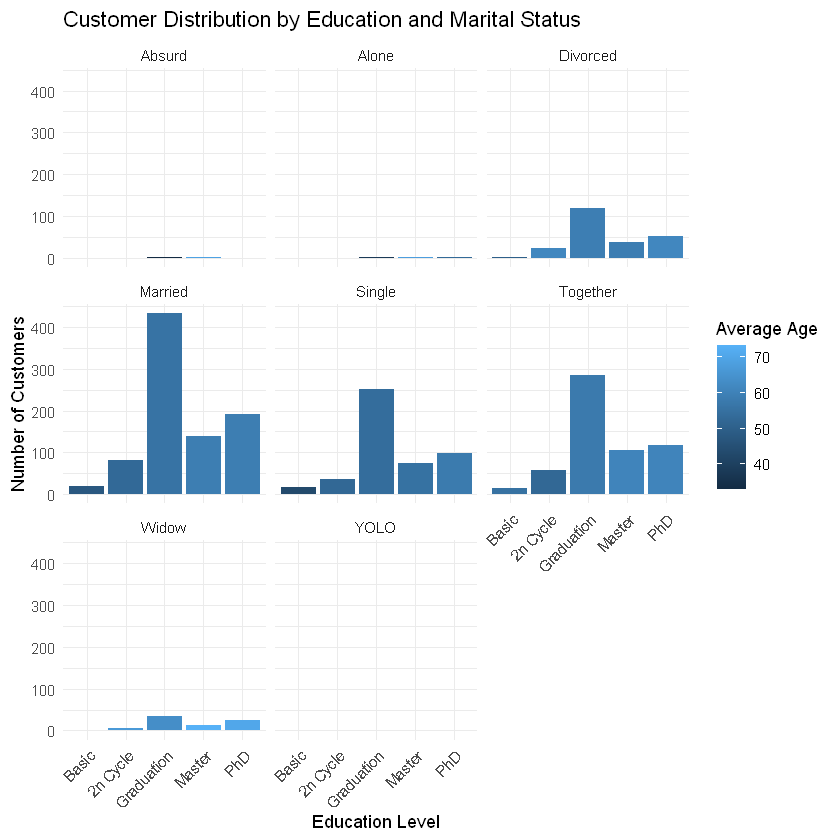

In [88]:
# Customer Distribution
cpa_cleaned |>
  group_by(Education, Marital_Status) |>
  summarise(
    n = n(),
    avg_age = mean(Age, na.rm = TRUE)
  ) |>
  ggplot(aes(x = Education, y = n, fill = avg_age)) +
  geom_col() +
  facet_wrap(~Marital_Status) +
  labs(
    title = "Customer Distribution by Education and Marital Status",
    x = "Education Level",
    y = "Number of Customers",
    fill = "Average Age"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
  scale_x_discrete(limits = c("Basic","2n Cycle","Graduation","Master","PhD"))

cpa_cleaned |> count(Marital_Status) |> mutate(pct = n / sum(n) * 100)
cpa_cleaned |> count(Education) |> mutate(pct = n / sum(n) * 100)

# There is no strong evidence of class imbalance in the dataset. Although some categories contain fewer observations, 
# the largest category accounts for approximately 50% of the observations. This suggests that the distribution across 
# categories is relatively balanced, and no single class overwhelmingly dominates the dataset. However, minor imbalance 
# exists because some categories like YOLO or Absurd have very few observations, but overall the distribution is not severely skewed.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 24 rows containing non-finite outside the scale range
(`stat_smooth()`)."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 24 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`)."


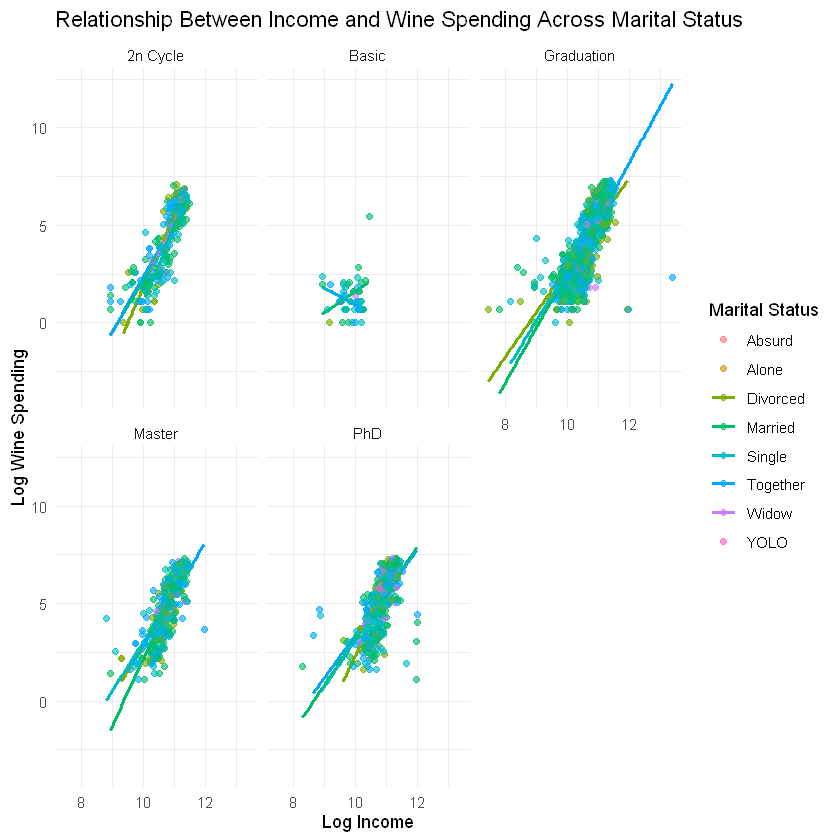

In [103]:
cpa_cleaned |>
  ggplot(aes(x = log(Income), y = log(MntWines + 1), color = Marital_Status)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1) +
  facet_wrap(~Education) + 
  labs(
    title = "Relationship Between Income and Wine Spending Across Marital Status",
    x = "Log Income",
    y = "Log Wine Spending",
    color = "Marital Status"
  ) +  
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  geom_point(alpha = 0.4) + 
  theme_minimal()

To explore whether demographics, family structure, and purchasing behaviour influence wine spending, I created a faceted scatter plot showing the relationship between income and wine expenditures. Both income and wine spending are log-transformed to reduce skewness and make patterns easier to interpret. Each point represents an individual customer, while regression lines indicate the relationship between income and wine spending. The points are coloured by marital status to incorporate family structure, and the plots are faceted by education level to examine differences across education groups.

This visualization allows us to assess whether higher-income customers tend to spend more on wine and whether this relationship differs across demographic groups. The positive slope of the regression lines suggests that wine spending generally increases with income. Faceting by education reveals whether this relationship varies across education levels, while the color coding allows us to observe potential differences in spending patterns between marital status groups. Overall, this plot provides a clear way to explore how demographic characteristics and household structure may influence wine purchasing behaviour.